<a href="https://colab.research.google.com/github/sete50/navaraj/blob/main/bigdatapredictionfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['PYSPARK_PYTHON']='python'

In [ ]:
# import Sparksession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Students performance Analysis") \
    .getOrCreate()

In [ ]:
# Read csv file and display few rows
df = spark.read.csv("/content/StudentPerformanceFactors.csv", header=True, inferSchema=True)
df.show(5)

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|

In [ ]:
# Print the schema to see data types
df.printSchema()

root
 |-- Hours_Studied: integer (nullable = true)
 |-- Attendance: integer (nullable = true)
 |-- Parental_Involvement: string (nullable = true)
 |-- Access_to_Resources: string (nullable = true)
 |-- Extracurricular_Activities: string (nullable = true)
 |-- Sleep_Hours: integer (nullable = true)
 |-- Previous_Scores: integer (nullable = true)
 |-- Motivation_Level: string (nullable = true)
 |-- Internet_Access: string (nullable = true)
 |-- Tutoring_Sessions: integer (nullable = true)
 |-- Family_Income: string (nullable = true)
 |-- Teacher_Quality: string (nullable = true)
 |-- School_Type: string (nullable = true)
 |-- Peer_Influence: string (nullable = true)
 |-- Physical_Activity: integer (nullable = true)
 |-- Learning_Disabilities: string (nullable = true)
 |-- Parental_Education_Level: string (nullable = true)
 |-- Distance_from_Home: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Exam_Score: integer (nullable = true)



In [ ]:
from pyspark.sql.functions import col, count, when

# Count null in each column
null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show()

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|

In [ ]:
from pyspark.sql.functions import col, mode

# Get the modes for categorical columns with nulls
mode_teacher_quality = df.groupBy("Teacher_Quality").count().orderBy(col("count").desc()).first()[0]
mode_parental_education = df.groupBy("Parental_Education_Level").count().orderBy(col("count").desc()).first()[0]
mode_distance_from_home = df.groupBy("Distance_from_Home").count().orderBy(col("count").desc()).first()[0]

# Fill null values with their respective modes
df_imp_cat = df.fillna({
    "Teacher_Quality": mode_teacher_quality,
    "Parental_Education_Level": mode_parental_education,
    "Distance_from_Home": mode_distance_from_home
})

# Display the DataFrame with imputed values
df_imp_cat.show(20)

# Show the null count
from pyspark.sql.functions import count, when
null_after_imp = df_imp_cat.select([count(when(col(c).isNull(), c)).alias(c) for c in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']])
null_after_imp.show()

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|

In [ ]:
df_imp_cat.show(5)

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|

In [ ]:
from pyspark.sql.functions import count

duplicate_rows = df_imp_cat.groupBy(df_imp_cat.columns).agg(count('*').alias('count')).filter('count > 1')
duplicate_rows.show()

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+-----+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|count|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+-

In [ ]:
from pyspark.sql import functions as F

# 1. Define mapping
rank_map = {"Low": 0, "Medium": 1, "High": 2, }

# 2. List columns to index
cols_to_fix = ["Parental_Involvement", "Motivation_Level", "Access_to_Resources", "Family_Income", "Teacher_Quality"]

# 3. Loop through the columns
df_final = df_imp_cat
for col_name in cols_to_fix:
    mapping_expr = F.when(F.col(col_name) == "Low", rank_map["Low"]) \
                    .when(F.col(col_name) == "Medium", rank_map["Medium"]) \
                    .when(F.col(col_name) == "High", rank_map["High"]) \
                    .otherwise(-1)

    # Create the new column
    df_final = df_final.withColumn(f"{col_name}_num", mapping_expr)

df_final.select(*(F.col(f"{c}_num") for c in cols_to_fix)).show(5)

+------------------------+--------------------+-----------------------+-----------------+-------------------+
|Parental_Involvement_num|Motivation_Level_num|Access_to_Resources_num|Family_Income_num|Teacher_Quality_num|
+------------------------+--------------------+-----------------------+-----------------+-------------------+
|                       0|                   0|                      2|                0|                  1|
|                       0|                   0|                      1|                1|                  1|
|                       1|                   1|                      1|                1|                  1|
|                       0|                   1|                      1|                1|                  1|
|                       1|                   1|                      1|                1|                  2|
+------------------------+--------------------+-----------------------+-----------------+-------------------+
only showi

In [ ]:
# chaining ordinal variables
df_final1 = df \
    .withColumn("Peer_Influence_Num",
        F.when(F.col("Peer_Influence") == "Negative", -1)
         .when(F.col("Peer_Influence") == "Medium", 0)
         .when(F.col("Peer_Influence") == "Positive", 1)
         .otherwise(-1)) \
    .withColumn("Distance_from_Home_num",
        F.when(F.col("Distance_from_Home") == "Near", 0)
         .when(F.col("Distance_from_Home") == "Moderate", 1)
         .when(F.col("Distance_from_Home") == "Far", 2)
         .otherwise(-1)) \
    .withColumn("Parental_Education_Level_num",
        F.when(F.col("Parental_Education_Level") == "High School", 0)
         .when(F.col("Parental_Education_Level") == "College", 1)
         .when(F.col("Parental_Education_level") == "Postgraduate", 2)
         .otherwise(-1))

# Show the results for all three new features
df_features_final = df_final1.select(
    "Peer_Influence_num",
    "Distance_from_Home_num",
    "Parental_Education_Level_num",

)

df_features_final.show(5)

+------------------+----------------------+----------------------------+
|Peer_Influence_num|Distance_from_Home_num|Parental_Education_Level_num|
+------------------+----------------------+----------------------------+
|                 1|                     0|                           0|
|                -1|                     1|                           1|
|                -1|                     0|                           2|
|                -1|                     1|                           0|
|                -1|                     0|                           1|
+------------------+----------------------+----------------------------+
only showing top 5 rows


In [ ]:
# Chaining Binary conversions
df_binary = df \
    .withColumn("Extracurricular_Activities_num",
        F.when(F.col("Extracurricular_Activities") == "Yes", 1)
         .when(F.col("Extracurricular_Activities") == "No", 0)
         .otherwise(-1)) \
    .withColumn("Internet_Access_num",
        F.when(F.col("Internet_Access") == "Yes", 1)
         .when(F.col("Internet_Access") == "No", 0)
         .otherwise(-1)) \
    .withColumn("Learning_Disabilities_num",
        F.when(F.col("Learning_Disabilities") == "Yes", 1)
         .when(F.col("Learning_Disabilities") == "No", 0)
         .otherwise(-1))

# Select new binary columns
df_features_final = df_binary.select(
    "Extracurricular_Activities_num",
    "Internet_Access_num",
    "Learning_Disabilities_num"
    ,
)

df_features_final.show(5)

+------------------------------+-------------------+-------------------------+
|Extracurricular_Activities_num|Internet_Access_num|Learning_Disabilities_num|
+------------------------------+-------------------+-------------------------+
|                             0|                  1|                        0|
|                             0|                  1|                        0|
|                             1|                  1|                        0|
|                             1|                  1|                        0|
|                             1|                  1|                        0|
+------------------------------+-------------------+-------------------------+
only showing top 5 rows


In [ ]:
# 1. Chain nominal features
df_final = df \
    .withColumn("Gender_num",
        F.when(F.col("Gender") == "Male", 0)
         .when(F.col("Gender") == "Female", 1)
         .otherwise(-1)) \
    .withColumn("School_Type_num",
        F.when(F.col("School_Type") == "Public", 0)
         .when(F.col("School_Type") == "Private", 1)
         .otherwise(-1))

# 2. Select and show just these two numeric columns
df_final.select("Gender_num", "School_Type_num").show(5)

+----------+---------------+
|Gender_num|School_Type_num|
+----------+---------------+
|         0|              0|
|         1|              0|
|         0|              0|
|         0|              0|
|         1|              0|
+----------+---------------+
only showing top 5 rows


In [ ]:
# 1. Transform all categorical features in a single chain
df_numeric = df \
    .withColumn("Parental_Involvement_num",
        F.when(F.col("Parental_Involvement") == "Low", 0)
         .when(F.col("Parental_Involvement") == "Medium", 1)
         .when(F.col("Parental_Involvement") == "High", 2).otherwise(-1)) \
    .withColumn("Access_to_Resources_num",
        F.when(F.col("Access_to_Resources") == "Low", 0)
         .when(F.col("Access_to_Resources") == "Medium", 1)
         .when(F.col("Access_to_Resources") == "High", 2).otherwise(-1)) \
    .withColumn("Motivation_Level_num",
        F.when(F.col("Motivation_Level") == "Low", 0)
         .when(F.col("Motivation_Level") == "Medium", 1)
         .when(F.col("Motivation_Level") == "High", 2).otherwise(-1)) \
    .withColumn("Peer_Influence_num",
        F.when(F.col("Peer_Influence") == "Negative", 0)
         .when(F.col("Peer_Influence") == "Neutral", 1)
         .when(F.col("Peer_Influence") == "Positive", 2).otherwise(-1)) \
    .withColumn("Distance_from_Home_num",
        F.when(F.col("Distance_from_Home") == "Near", 0)
         .when(F.col("Distance_from_Home") == "Moderate", 1)
         .when(F.col("Distance_from_Home") == "Far", 2).otherwise(-1)) \
    .withColumn("Parental_Education_num",
        F.when(F.col("Parental_Education_Level") == "High School", 0)
         .when(F.col("Parental_Education_Level") == "College", 1)
         .when(F.col("Parental_Education_Level") == "Postgraduate", 2).otherwise(-1)) \
    .withColumn("Teacher_Quality_num",
        F.when(F.col("Teacher_Quality") == "Low", 0)
         .when(F.col("Teacher_Quality") == "Medium", 1)
         .when(F.col("Teacher_Quality") == "High", 2).otherwise(-1)) \
    .withColumn("Family_Income_num",
        F.when(F.col("Family_Income") == "Low", 0)
         .when(F.col("Family_Income") == "Medium", 1)
         .when(F.col("Family_Income") == "High", 2).otherwise(-1)) \
    .withColumn("Extracurricular_Activities_num", F.when(F.col("Extracurricular_Activities") == "Yes", 1).otherwise(0)) \
    .withColumn("Internet_Access_num", F.when(F.col("Internet_Access") == "Yes", 1).otherwise(0)) \
    .withColumn("Learning_Disabilities_num", F.when(F.col("Learning_Disabilities") == "Yes", 1).otherwise(0)) \
    .withColumn("Gender_num", F.when(F.col("Gender") == "Male", 0).otherwise(1)) \
    .withColumn("School_Type_num", F.when(F.col("School_Type") == "Public", 0).otherwise(1))

# 2. from pyspark.ml.feature import VectorAssembler, StandardScaler

# 1. Assemble numeric columns into a single Vector column
numeric_vars = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
                "Tutoring_Sessions", "Physical_Activity"]
assembler = VectorAssembler(inputCols= numeric_vars, outputCol="numeric_vector")
df_assembled = assembler.transform(df_numeric)

# 2. Define and Fit the Scaler on the DATAFRAME
std_scaler = StandardScaler(inputCol="numeric_vector",
                            outputCol="scaled_features",
                            withMean=True,
                            withStd=True)

# FIX: Pass the DataFrame (df_assembled), not the list (numeric_vars)
std_model = std_scaler.fit(df_assembled)
df_scaled = std_model.transform(df_assembled)

# 3. Final Selection
# We keep the scaled features vector, the _num columns, and the target
created_num_cols = [c for c in df_scaled.columns if c.endswith('_num')]
df_model_final = df_scaled.select("scaled_features", *created_num_cols, "Exam_Score")

df_model_final.show(5)

+--------------------+------------------------+-----------------------+--------------------+------------------+----------------------+----------------------+-------------------+-----------------+------------------------------+-------------------+-------------------------+----------+---------------+----------+
|     scaled_features|Parental_Involvement_num|Access_to_Resources_num|Motivation_Level_num|Peer_Influence_num|Distance_from_Home_num|Parental_Education_num|Teacher_Quality_num|Family_Income_num|Extracurricular_Activities_num|Internet_Access_num|Learning_Disabilities_num|Gender_num|School_Type_num|Exam_Score|
+--------------------+------------------------+-----------------------+--------------------+------------------+----------------------+----------------------+-------------------+-----------------+------------------------------+-------------------+-------------------------+----------+---------------+----------+
|[0.50490329235352...|                       0|                    

In [ ]:
from pyspark.ml.feature import VectorAssembler

# 1.  Numeric/encoded columns

final_inputs = ["scaled_features"] + [c for c in df_model_final.columns if c.endswith('_num')]

# 2.  VectorAssembler to merge 'features'
final_assembler = VectorAssembler(inputCols=final_inputs, outputCol="features")

# 3. Transform the data
df_ready_for_ml = final_assembler.transform(df_model_final)

# 4. Select only 'features' and 'label' (Exam_Score)
train_df = df_ready_for_ml.select(F.col("features"), F.col("Exam_Score").alias("label"))

train_df.show(5, truncate=False)


+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                                                                  |label|
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|(19,[0,1,2,3,4,5,7,9,12,15],[0.5049032923535299,0.3483490418793696,-0.01979407902453241,-0.14378904602279843,-1.2138425865150193,0.031408953572775115,2.0,2.0,1.0,1.0])   |67   |
|[-0.16281008886740927,-1.383631331900267,0.6613490465750316,-1.116025828114752,0.4114199464882682,1.0011237024293427,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0] |61   |
|[0.6718316376587647,1.5607353035251152,-0.01979407902453241,1.1062296738097133,0.4114199464882682,1.0011

In [ ]:
from pyspark.ml.regression import RandomForestRegressor
import pandas as pd

# 1. Initialize the model using the standard Spark names
# 'features' contains BOTH your scaled numbers and your encoded categories
rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=100)

# 2. Fit the model on train_df
rf_model = rf.fit(train_df)

# 3. Extract importance scores
importances = rf_model.featureImportances

# 4. Map ALL features (Must match the exact order of your final VectorAssembler)
all_features = [
    "Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
    "Tutoring_Sessions", "Physical_Activity",
    "Parental_Involvement_num", "Access_to_Resources_num", "Motivation_Level_num",
    "Peer_Influence_num", "Distance_from_Home_num", "Parental_Education_num",
    "Teacher_Quality_num", "Family_Income_num", "Extracurricular_Activities_num",
    "Internet_Access_num", "Learning_Disabilities_num", "Gender_num", "School_Type_num"
]

# 5. Show Top 10
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances.toArray()
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                     Feature  Importance
1                 Attendance    0.553356
0              Hours_Studied    0.306685
3            Previous_Scores    0.041898
7    Access_to_Resources_num    0.030008
6   Parental_Involvement_num    0.019977
4          Tutoring_Sessions    0.019687
9         Peer_Influence_num    0.004462
11    Parental_Education_num    0.004084
8       Motivation_Level_num    0.003468
13         Family_Income_num    0.003214


In [ ]:
from pyspark.ml.feature import VectorAssembler

top_10_features = [
    "Attendance", "Hours_Studied", "Previous_Scores", "Access_to_Resources_num",
    "Parental_Involvement_num", "Tutoring_Sessions", "Peer_Influence_num",
    "Parental_Education_num", "Motivation_Level_num", "Family_Income_num"
]

# 2. DataFrame that still has individual columns

assembler_top = VectorAssembler(
    inputCols=top_10_features,
    outputCol="features"
)

# 3. Transform - Ensure you use the right source DF here
df_final_feature = assembler_top.transform(df_scaled)

# 4. Data set splitting

train_data, val_data, test_data = df_final_feature.randomSplit([0.6, 0.2, 0.2], seed=42)

print(f"Train count: {train_data.count()}, Val count: {val_data.count()}, Test count: {test_data.count()}")

Train count: 4052, Val count: 1289, Test count: 1266


In [ ]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="Exam_Score",
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_data)
predictions = lr_model.transform(test_data)



In [ ]:
# model evaluation
print(f"RMSE for LR: {lr_model.summary.rootMeanSquaredError:.4f}")
print(f"R² for LR: {lr_model.summary.r2:.4f}")

RMSE for LR: 2.1838
R² for LR: 0.6909


In [ ]:
# Random Forest Regressor
from pyspark.ml.regression import RandomForestRegressor
rf_reg  = RandomForestRegressor(featuresCol="features", labelCol="Exam_Score", numTrees=100)
model = rf_reg.fit(train_data)
predictions = model.transform(test_data)

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

reg_eval = RegressionEvaluator(labelCol="Exam_Score", predictionCol="prediction", metricName="rmse")
print(f"RMSE for RF: {reg_eval.evaluate(predictions):.2f}")

reg_eval.setMetricName("r2")
print(f"R²for RF: {reg_eval.evaluate(predictions):.4f}")


RMSE for RF: 2.47
R²for RF: 0.5734


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.evaluation import RegressionEvaluator

# 1. Define the categorical mapping
categorical_map = {
    "Parental_Involvement": "Parental_Involvement_num",
    "Family_Income": "Family_Income_num",
    "Parental_Education_Level": "Parental_Education_num",
    "Peer_Influence": "Peer_Influence_num",
    "Motivation_Level": "Motivation_Level_num",
    "Distance_from_Home": "Distance_from_Home_num"
}

indexers = [StringIndexer(inputCol=k, outputCol=v, handleInvalid="keep")
            for k, v in categorical_map.items()]

# 2. Features list
top_10_features = [
    "Attendance", "Hours_Studied", "Previous_Scores",
    "Parental_Involvement_num", "Tutoring_Sessions", "Family_Income_num",
    "Parental_Education_num", "Peer_Influence_num", "Motivation_Level_num",
    "Distance_from_Home_num"
]

assembler = VectorAssembler(inputCols=top_10_features, outputCol="features")

# 3. FIX: Change labelCol to "Exam_Score"
gbt = GBTRegressor(featuresCol="features", labelCol="Exam_Score", maxIter=50)

# 4. Pipeline
pipeline = Pipeline(stages=indexers + [assembler, gbt])

# 5. Split and Train
train_data, val_data, test_data = df.randomSplit([0.6, 0.2, 0.2], seed=42)
pipeline_model = pipeline.fit(train_data)

# 6. Predictions
predictions = pipeline_model.transform(test_data)

# 7. Evaluators
evaluator_rmse = RegressionEvaluator(labelCol="Exam_Score", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="Exam_Score", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"RMSE for GBT: {rmse:.4f}")
print(f"R²for GBT: {r2:.4f}")

RMSE for GBT: 2.4018
R²for GBT: 0.5977


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

# 1. Prepare the transformation stages
categorical_map = {
    "Parental_Involvement": "Parental_Involvement_num",
    "Family_Income": "Family_Income_num",
    "Parental_Education_Level": "Parental_Education_num",
    "Peer_Influence": "Peer_Influence_num",
    "Motivation_Level": "Motivation_Level_num",
    "Distance_from_Home": "Distance_from_Home_num"
}

indexers = [StringIndexer(inputCol=k, outputCol=v, handleInvalid="keep") for k, v in categorical_map.items()]

top_10_features = [
    "Attendance", "Hours_Studied", "Previous_Scores",
    "Parental_Involvement_num", "Tutoring_Sessions", "Family_Income_num",
    "Parental_Education_num", "Peer_Influence_num", "Motivation_Level_num",
    "Distance_from_Home_num"
]
assembler = VectorAssembler(inputCols=top_10_features, outputCol="features")

# 2. Transform the entire DataFrame once

prep_pipeline = Pipeline(stages=indexers + [assembler])
transformed_df = prep_pipeline.fit(df).transform(df)

# 3 split the transformed data
train_data, test_data = transformed_df.randomSplit([0.8, 0.2], seed=42)

models = [
    ("Linear Regression", LinearRegression(featuresCol="features", labelCol="Exam_Score")),
    ("Random Forest", RandomForestRegressor(featuresCol="features", labelCol="Exam_Score")),
    ("GBT", GBTRegressor(featuresCol="features", labelCol="Exam_Score", maxIter=50))
]

results = []
for name, model in models:
    m = model.fit(train_data)
    predictions = m.transform(test_data)

    rmse = evaluator_rmse.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    results.append((name, rmse, r2))

/tmp/ipython-input-177/3623694057.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="RMSE", data=pdf_rmse, ax=ax1, palette="viridis_r")
/tmp/ipython-input-177/3623694057.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2", data=pdf_r2, ax=ax2, palette= "viridis_r")


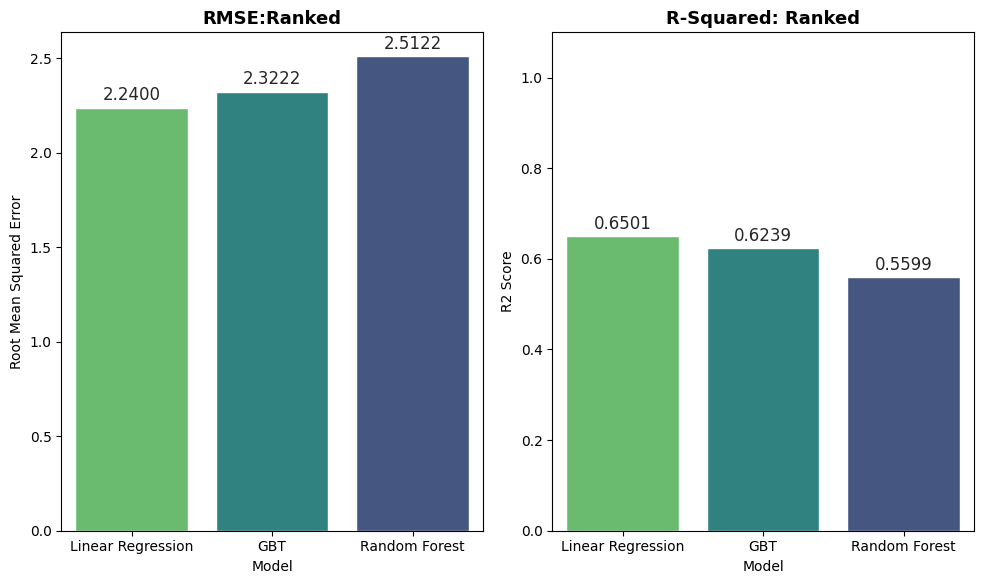

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Convert results to a Pandas DataFrame
pdf = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])

# 2. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot 1: RMSE
pdf_rmse = pdf.sort_values("RMSE", ascending=True)
sns.barplot(x="Model", y="RMSE", data=pdf_rmse, ax=ax1, palette="viridis_r")
ax1.set_title("RMSE:Ranked", fontsize=13, fontweight='bold')
ax1.set_ylabel("Root Mean Squared Error")

#  Data labels
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

#  R2
pdf_r2 = pdf.sort_values("R2", ascending=False)
sns.barplot(x="Model", y="R2", data=pdf_r2, ax=ax2, palette= "viridis_r")
ax2.set_title("R-Squared: Ranked", fontsize=13, fontweight='bold')
ax2.set_ylabel("R2 Score")
ax2.set_ylim(0, 1.1)

#  Data labels
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
# model Optimization
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# 1. Define the model
gbt = GBTRegressor(featuresCol="features", labelCol="Exam_Score")

# 2. Build the Parameter Grid
paramGrid = (ParamGridBuilder()
             .addGrid(gbt.maxDepth, [3, 5, 10])
             .addGrid(gbt.stepSize, [0.01, 0.1])
             .addGrid(gbt.maxIter, [20, 50])
             .build())

# 3. Set up the CrossValidator

cv = CrossValidator(estimator=gbt,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator_rmse,
                    numFolds=3)

# 4. Run the optimization
cv_model = cv.fit(train_data)

# 5. Extract the best model
best_gbt = cv_model.bestModel
predictions = best_gbt.transform(test_data)

print(f"Optimized RMSE: {evaluator_rmse.evaluate(predictions):.4f}")
print(f"Optimized R2: {evaluator_r2.evaluate(predictions):.4f}")

Optimized RMSE: 2.2265
Optimized R2: 0.6543
